<a href="https://colab.research.google.com/github/deviyazhyoga06-oss/-data-science-module-1/blob/main/Hospital_Patient_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HOSPITAL PATIENT DATA ANALYSIS

A Data Science Mini Project

Objective:
To analyze hospital patient data and identify useful patterns
related to patient demographics, medical conditions, admissions,
and billing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
!pip -q install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd

diabetes = fetch_ucirepo(id=296)

df = pd.concat(
    [diabetes.data.features, diabetes.data.targets],
    axis=1
)

print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)

/usr/local/lib/python3.13/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Dataset loaded successfully!
Rows and Columns: (101766, 48)


In [ ]:
print(df.head())

              race  gender      age weight  admission_type_id  \
0        Caucasian  Female   [0-10)    NaN                  6   
1        Caucasian  Female  [10-20)    NaN                  1   
2  AfricanAmerican  Female  [20-30)    NaN                  1   
3        Caucasian    Male  [30-40)    NaN                  1   
4        Caucasian    Male  [40-50)    NaN                  1   

   discharge_disposition_id  admission_source_id  time_in_hospital payer_code  \
0                        25                    1                 1        NaN   
1                         1                    7                 3        NaN   
2                         1                    7                 2        NaN   
3                         1                    7                 2        NaN   
4                         1                    7                 1        NaN   

          medical_specialty  ...  citoglipton  insulin  glyburide-metformin  \
0  Pediatrics-Endocrinology  ...           

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

In [ ]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0].sort_values(ascending=False))

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


In [ ]:
df = df.replace("?", pd.NA)

print("Data cleaning completed!")

Data cleaning completed!


In [ ]:
print(df.head())

              race  gender      age weight  admission_type_id  \
0        Caucasian  Female   [0-10)    NaN                  6   
1        Caucasian  Female  [10-20)    NaN                  1   
2  AfricanAmerican  Female  [20-30)    NaN                  1   
3        Caucasian    Male  [30-40)    NaN                  1   
4        Caucasian    Male  [40-50)    NaN                  1   

   discharge_disposition_id  admission_source_id  time_in_hospital payer_code  \
0                        25                    1                 1        NaN   
1                         1                    7                 3        NaN   
2                         1                    7                 2        NaN   
3                         1                    7                 2        NaN   
4                         1                    7                 1        NaN   

          medical_specialty  ...  citoglipton  insulin  glyburide-metformin  \
0  Pediatrics-Endocrinology  ...           

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Visualization libraries ready!")

Visualization libraries ready!


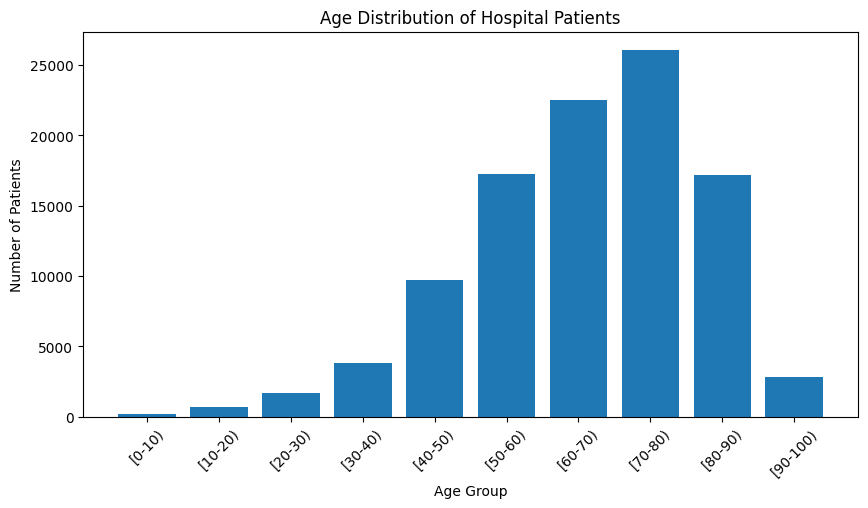

In [ ]:
age_counts = df["age"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(age_counts.index, age_counts.values)

plt.title("Age Distribution of Hospital Patients")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


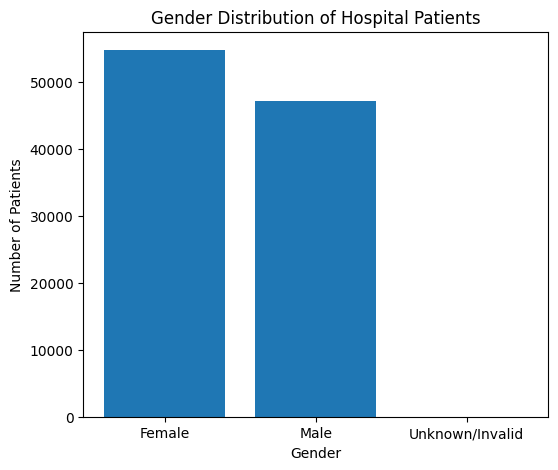

In [ ]:
gender_counts = df["gender"].value_counts()

print(gender_counts)

plt.figure(figsize=(6, 5))
plt.bar(gender_counts.index, gender_counts.values)

plt.title("Gender Distribution of Hospital Patients")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

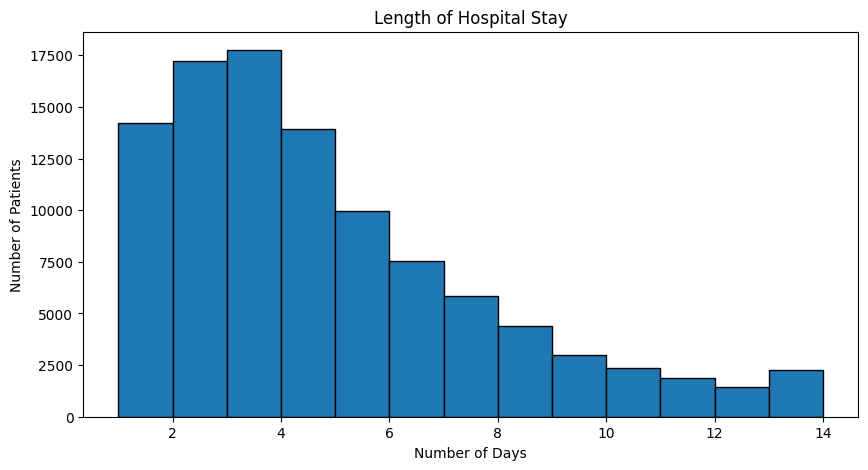

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df["time_in_hospital"], bins=range(1, 15), edgecolor="black")

plt.title("Length of Hospital Stay")
plt.xlabel("Number of Days")
plt.ylabel("Number of Patients")

plt.show()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


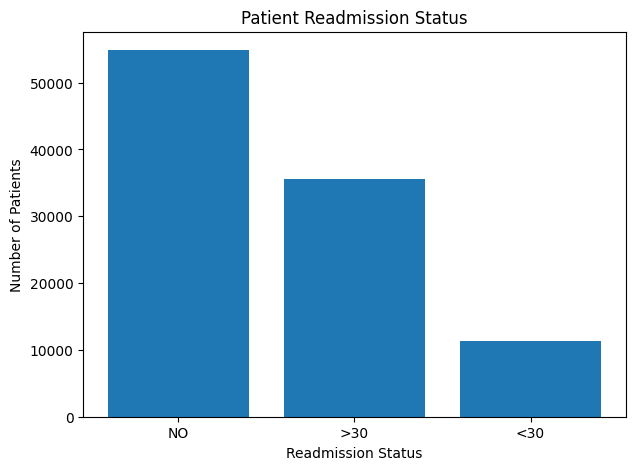

In [ ]:
readmission_counts = df["readmitted"].value_counts()

print(readmission_counts)

plt.figure(figsize=(7, 5))
plt.bar(readmission_counts.index, readmission_counts.values)

plt.title("Patient Readmission Status")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")

plt.show()

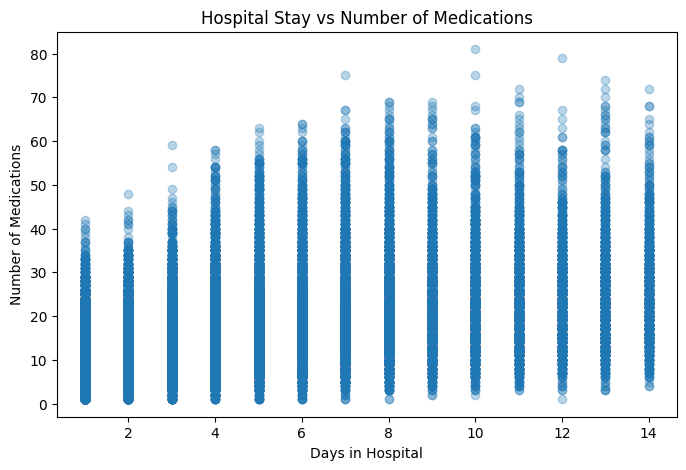

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["time_in_hospital"], df["num_medications"], alpha=0.3)

plt.title("Hospital Stay vs Number of Medications")
plt.xlabel("Days in Hospital")
plt.ylabel("Number of Medications")

plt.show()

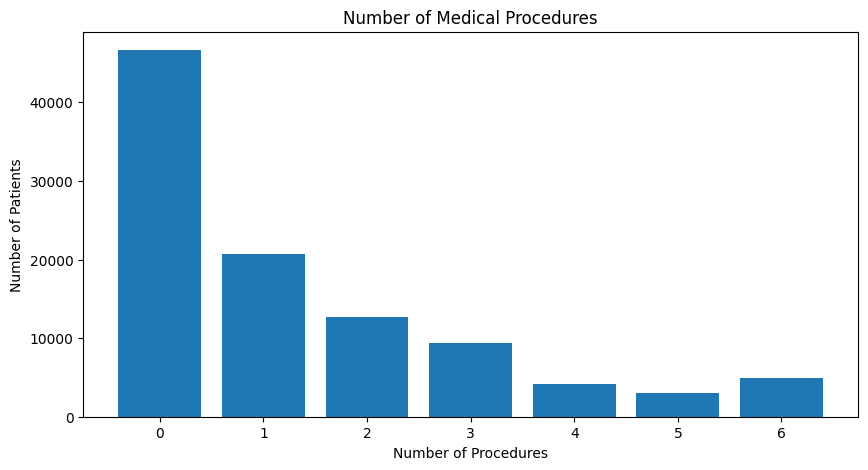

In [ ]:
procedure_counts = df["num_procedures"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(procedure_counts.index, procedure_counts.values)

plt.title("Number of Medical Procedures")
plt.xlabel("Number of Procedures")
plt.ylabel("Number of Patients")

plt.show()

In [ ]:
age_counts = df["age"].value_counts()

most_common_age = age_counts.idxmax()
most_common_count = age_counts.max()

print("Most common age group:", most_common_age)
print("Number of patients:", most_common_count)

Most common age group: [70-80)
Number of patients: 26068


In [ ]:
average_stay = df["time_in_hospital"].mean()

print("Average hospital stay:", round(average_stay, 2), "days")

Average hospital stay: 4.4 days


In [ ]:
average_medications = df["num_medications"].mean()

print("Average number of medications:", round(average_medications, 2))

Average number of medications: 16.02


In [ ]:
readmission_counts = df["readmitted"].value_counts()

most_common_status = readmission_counts.idxmax()
most_common_status_count = readmission_counts.max()

print("Most common readmission status:", most_common_status)
print("Number of patients:", most_common_status_count)

Most common readmission status: NO
Number of patients: 54864


In [ ]:
print("===== HOSPITAL PATIENT DATA ANALYSIS SUMMARY =====")

print("Total patients:", len(df))
print("Total columns:", len(df.columns))

print("Most common age group:", df["age"].value_counts().idxmax())

print("Average hospital stay:",
      round(df["time_in_hospital"].mean(), 2), "days")

print("Average number of medications:",
      round(df["num_medications"].mean(), 2))

print("Most common readmission status:",
      df["readmitted"].value_counts().idxmax())

print("===================================================")

===== HOSPITAL PATIENT DATA ANALYSIS SUMMARY =====
Total patients: 101766
Total columns: 48
Most common age group: [70-80)
Average hospital stay: 4.4 days
Average number of medications: 16.02
Most common readmission status: NO


KEY INSIGHTS

1. The dataset contains 101,766 hospital patient records.

2. The analysis shows the distribution of patients across different age groups.

3. The average hospital stay provides information about patient hospitalization.

4. The average number of medications shows medication usage during hospital stays.

5. The readmission analysis shows how many patients were readmitted within 30 days,
after 30 days, or not readmitted.

6. The visualizations help identify patterns in patient demographics,
hospital stay, medications, procedures, and readmission.

CONCLUSION

This mini project analyzed a real-world hospital patient dataset using Python.
The data was explored, cleaned, and analyzed to understand patient
demographics, hospital stay, medications, procedures, and readmission.

Different visualizations were created to identify useful patterns and trends.
This project helped in understanding how data analysis and visualization
can be used to gain meaningful insights from healthcare data.